In [1]:
%matplotlib widget
from easydynamics.analysis import Analysis


from easydynamics.sample import GaussianComponent
from easydynamics.sample import LorentzianComponent
from easydynamics.sample import PolynomialComponent
from easydynamics.sample import SampleModel
from easydynamics.sample import DeltaFunctionComponent

from easydynamics.experiment  import Experiment

from easydynamics.job import Job
from easydynamics.experiment  import Data


In [2]:
analysis=Analysis()

experiment=Experiment()
data=Data()
data.append(data.load_example_vanadium_data_1d())
experiment.set_data(data)
analysis.set_experiment(experiment)

theory= SampleModel()
theory.add_component(GaussianComponent(width=0.5e-3,area=5e-5))
theory.add_component(LorentzianComponent(width=2e-3, area=2e-6))
analysis.set_theory(theory)

background=SampleModel()
background.add_component(PolynomialComponent(coefficients=[1e-3]))
analysis.set_background_model(background)

analysis.set_resolution_model(None)

analysis.fit()
    
    


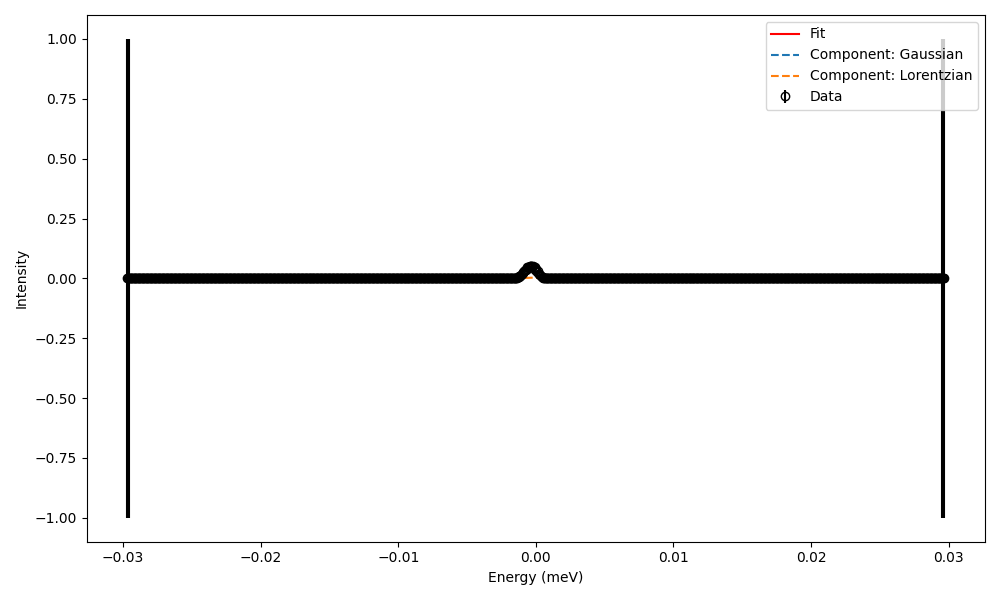

(0.0, 0.07)

In [3]:
fig=analysis.plot_data_and_model(plot_individual_components=True)

fig.axes[0].set_xlim(-0.02, 0.02)
fig.axes[0].set_ylim(0, 0.07)

In [10]:
theory.get_parameters()


[<Parameter 'temperature': -1.0000 K (fixed), bounds=[-inf:inf]>,
 <Parameter 'Gaussianarea': 0.0001 ± 0.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Gaussiancenter': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Gaussianwidth': 0.0004 ± 0.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Lorentzianarea': 0.0000 ± 0.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Lorentziancenter': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Lorentzianwidth': 0.0005 ± 0.0004 meV, bounds=[0.0:inf]>]

In [5]:
theory2=theory.copy()
theory2.get_parameters()

Detailed balance set to False for temperature -1.0 K


C:\Users\henrikjacobsen3\Documents\easyScience\EasyQENSLib\src\easydynamics\sample\sample_model.py:169: UserWarning: Temperature is negative. Disabling detailed balance.
  warnings.warn("Temperature is negative. Disabling detailed balance.")


[<Parameter 'temperature': -1.0000 K (fixed), bounds=[-inf:inf]>,
 <Parameter 'Gaussianarea': 0.0001 meV, bounds=[0.0:inf]>,
 <Parameter 'Gaussiancenter': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Gaussianwidth': 0.0004 meV, bounds=[0.0:inf]>,
 <Parameter 'Lorentzianarea': 0.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Lorentziancenter': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Lorentzianwidth': 0.0005 meV, bounds=[0.0:inf]>]

In [14]:
# data.append(data.load_example_vanadium_data_1d())

Vdata=Data()
Vdata.append(data.load_example_vanadium_data())

myexperiment=Experiment()
myexperiment.set_data(Vdata)


myexperiment._data.data

<scipp.DataArray>
Dimensions: Sizes[Q:16, energy:1024, ]
Coordinates:
* Q                         float64           [1/Å]  (Q)  [0.5708, 0.7002, ..., 1.8965, 1.9361]
* energy                    float64            [meV]  (energy)  [-0.029678, -0.02962, ..., 0.02962, 0.029678]
Data:
                            float64  [dimensionless]  (Q, energy)  [0, 0, ..., 0, 0]  [1, 1, ..., 1, 1]

In [7]:


AllAnalyses=[]

for i in range(Vdata.data.sizes['Q']):
    print(i)
    this_analysis=Analysis()
    this_analysis.set_theory(theory.copy())

    this_analysis.set_background_model(background.copy())
    this_analysis.set_resolution_model(None)

    this_experiment=Experiment()
    this_data=Data()
    this_data.append(Vdata.data['Q',i])
    this_experiment.set_data(this_data)

    this_analysis.set_experiment(this_experiment)
    AllAnalyses.append(this_analysis)



0
Detailed balance set to False for temperature -1.0 K
Detailed balance set to False for temperature -1.0 K
1
Detailed balance set to False for temperature -1.0 K
Detailed balance set to False for temperature -1.0 K
2
Detailed balance set to False for temperature -1.0 K
Detailed balance set to False for temperature -1.0 K
3
Detailed balance set to False for temperature -1.0 K
Detailed balance set to False for temperature -1.0 K
4
Detailed balance set to False for temperature -1.0 K
Detailed balance set to False for temperature -1.0 K
5
Detailed balance set to False for temperature -1.0 K
Detailed balance set to False for temperature -1.0 K
6
Detailed balance set to False for temperature -1.0 K
Detailed balance set to False for temperature -1.0 K
7
Detailed balance set to False for temperature -1.0 K
Detailed balance set to False for temperature -1.0 K
8
Detailed balance set to False for temperature -1.0 K
Detailed balance set to False for temperature -1.0 K
9
Detailed balance set to Fa

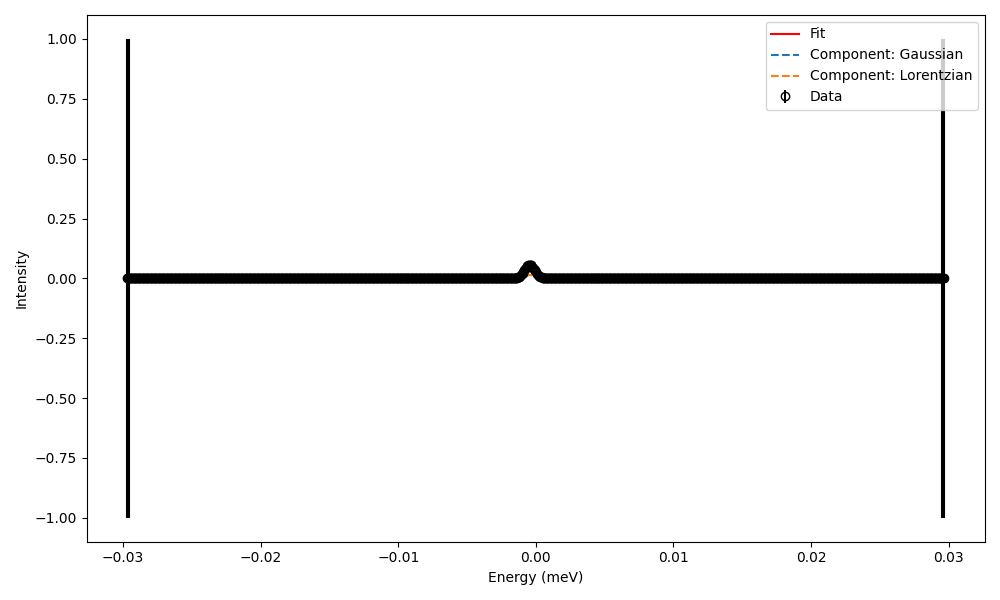

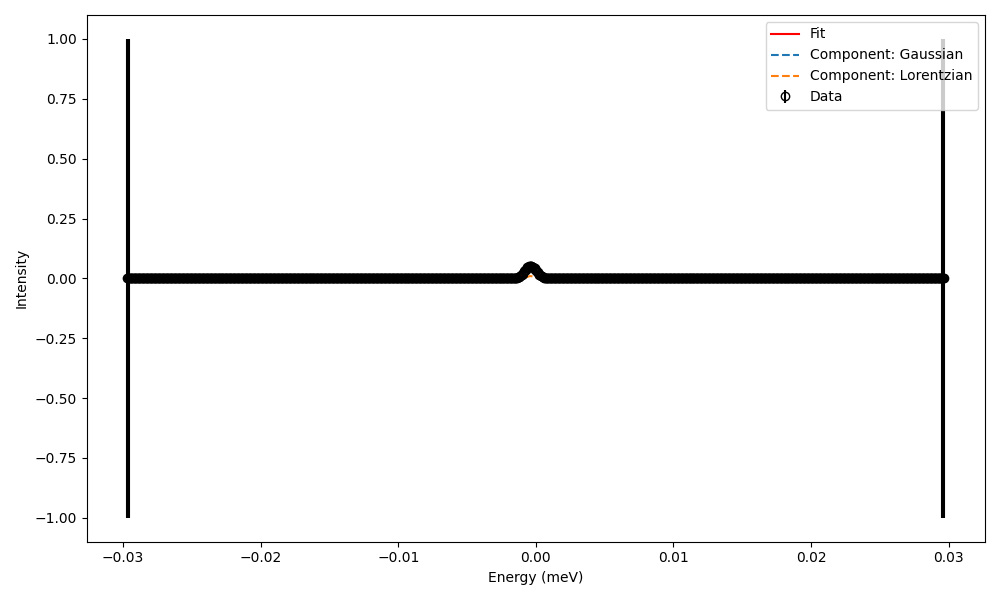

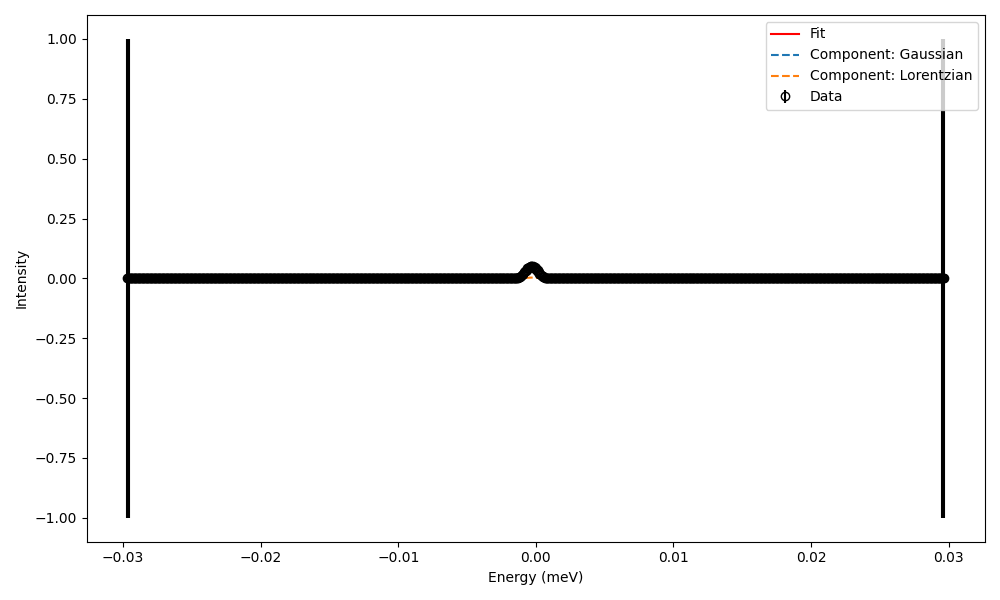

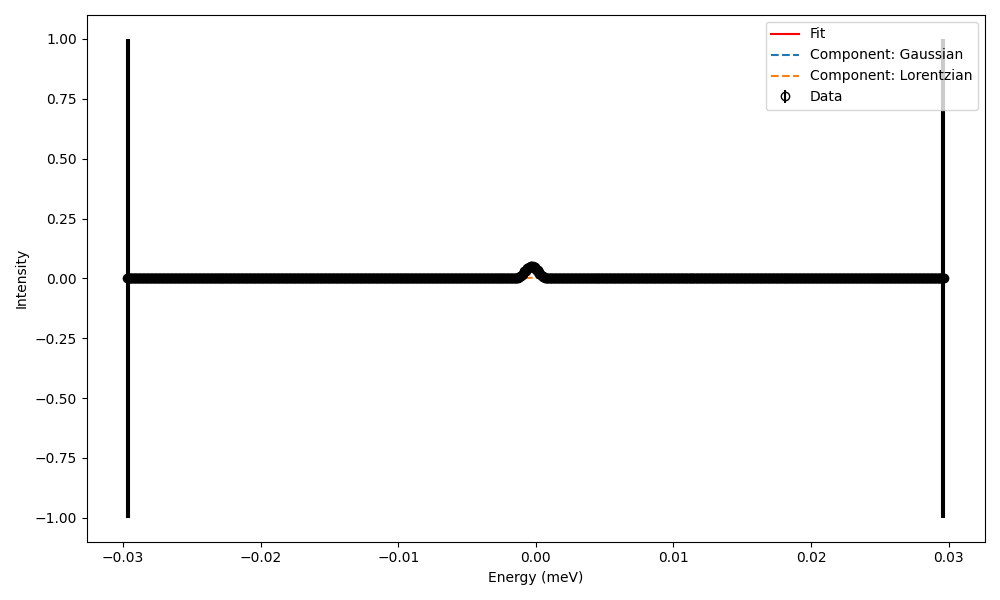

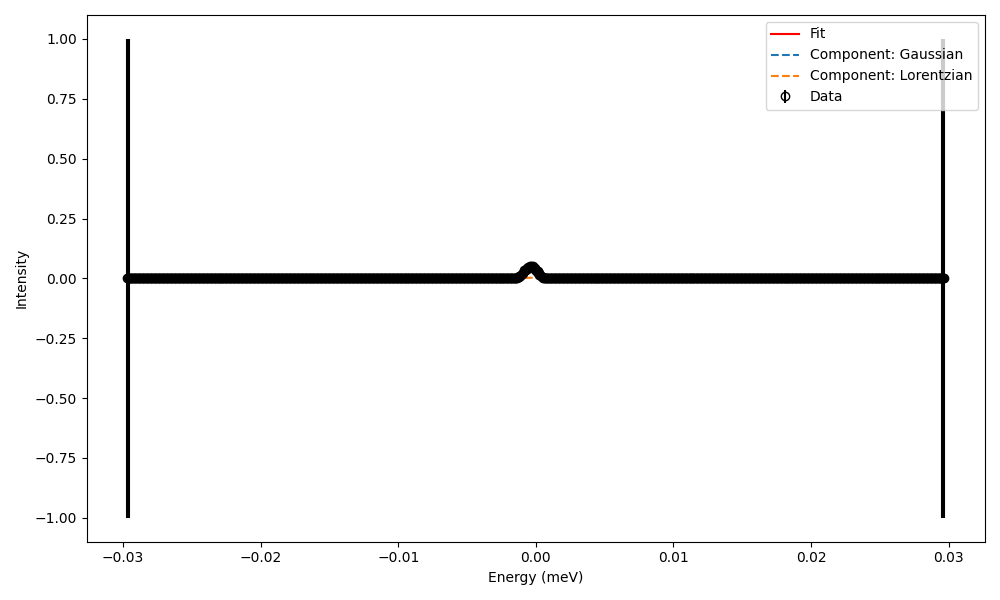

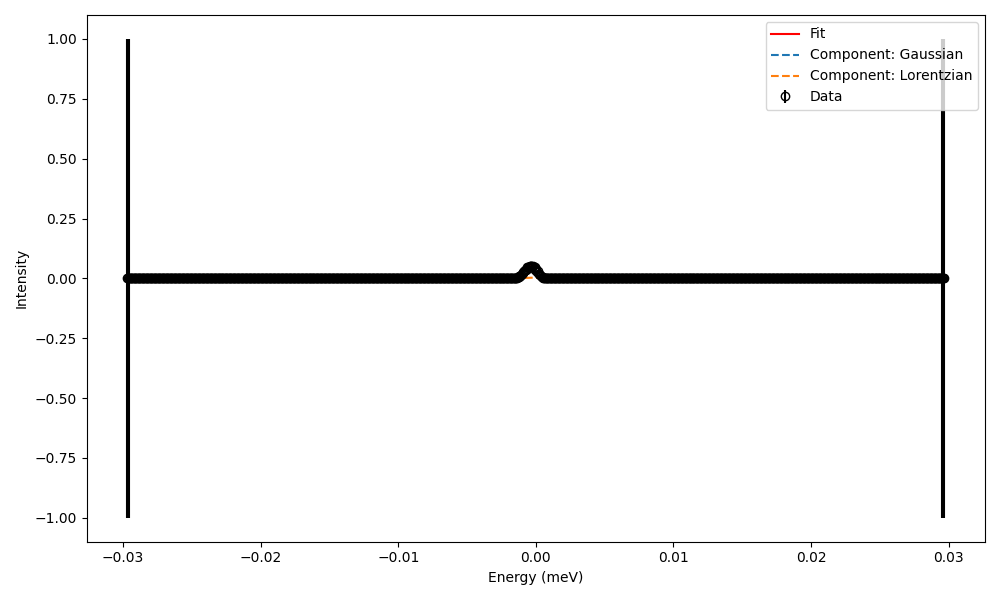

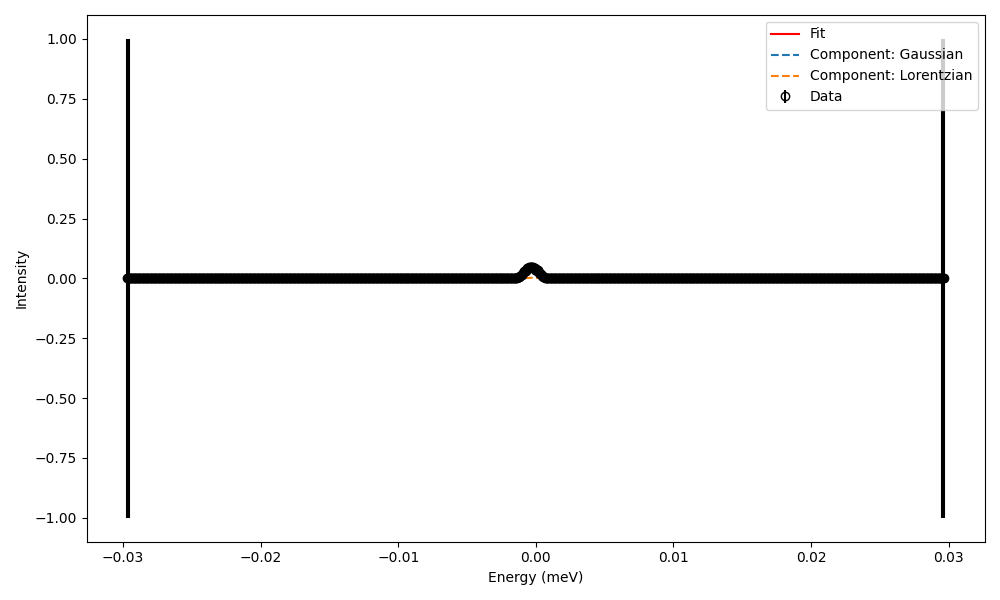

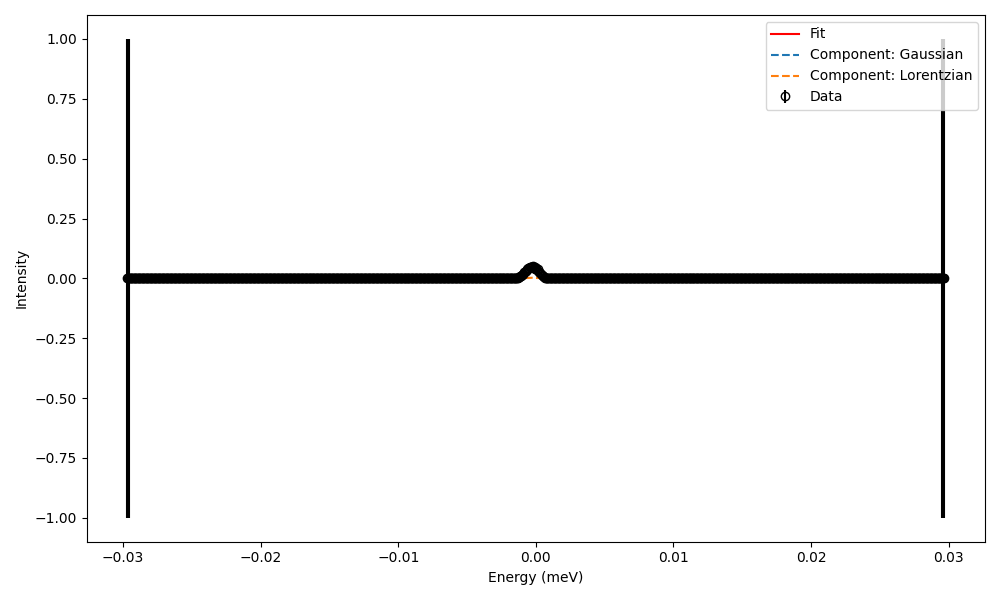

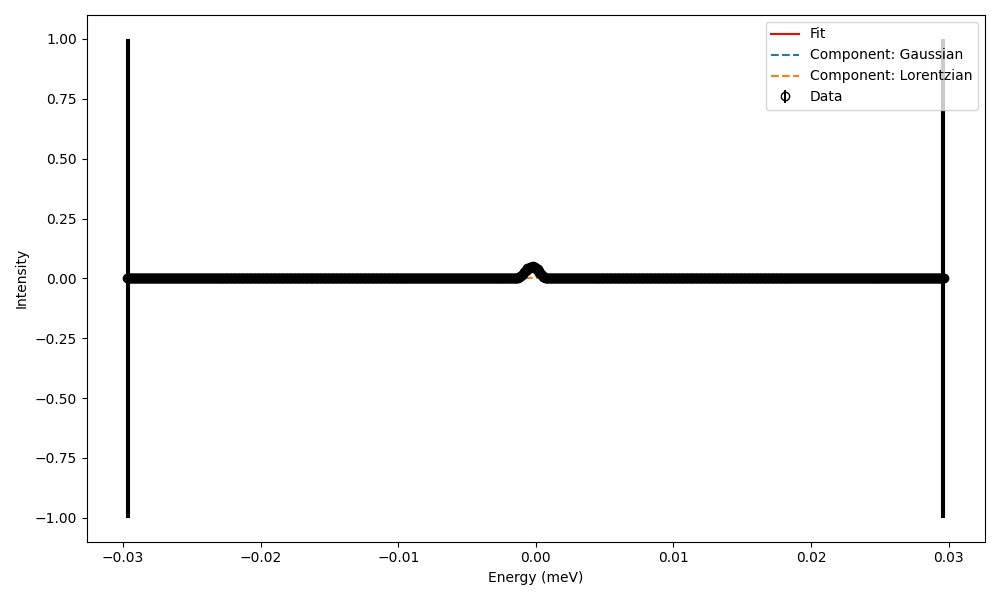

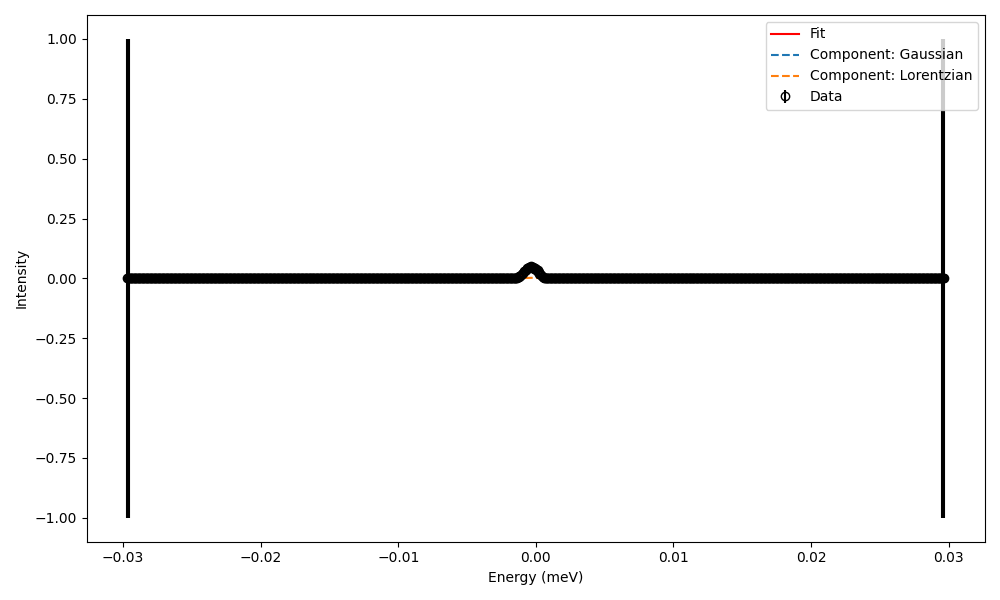

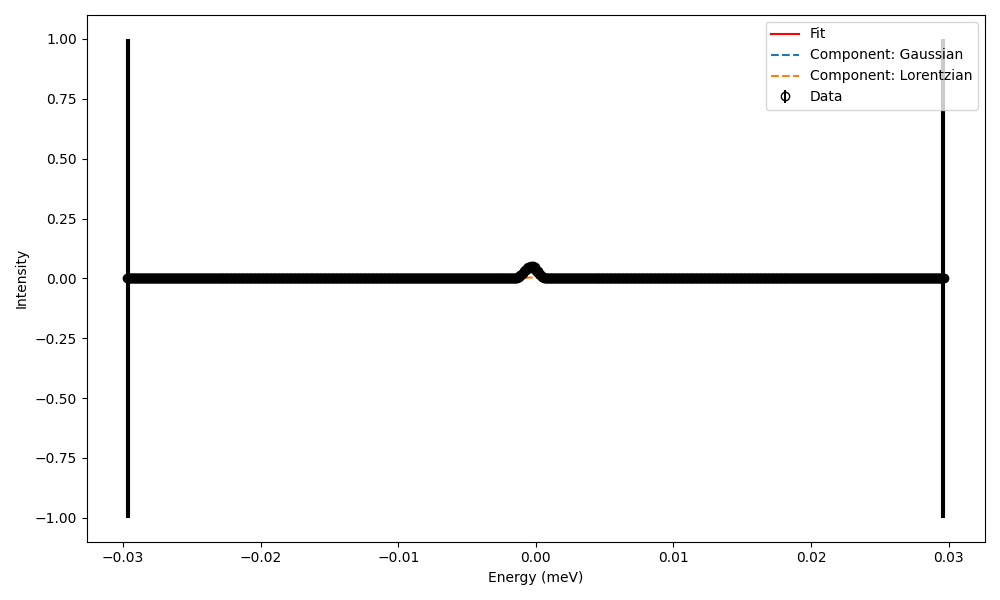

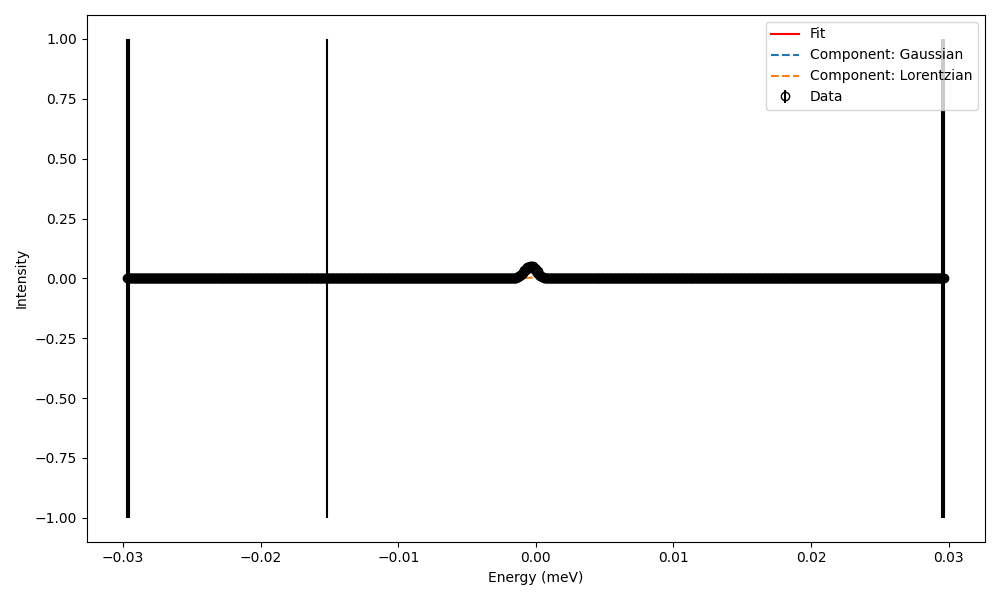

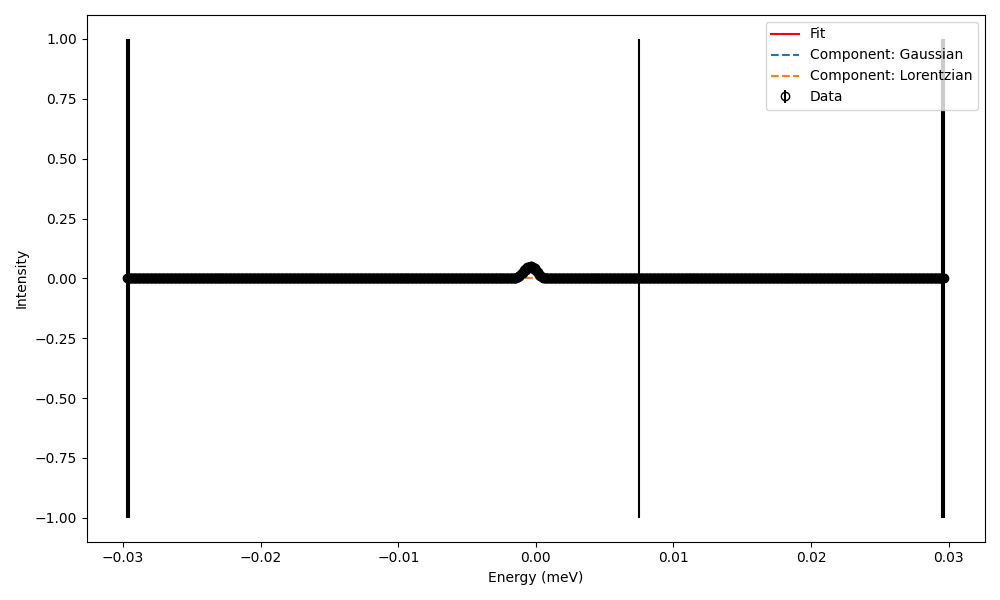

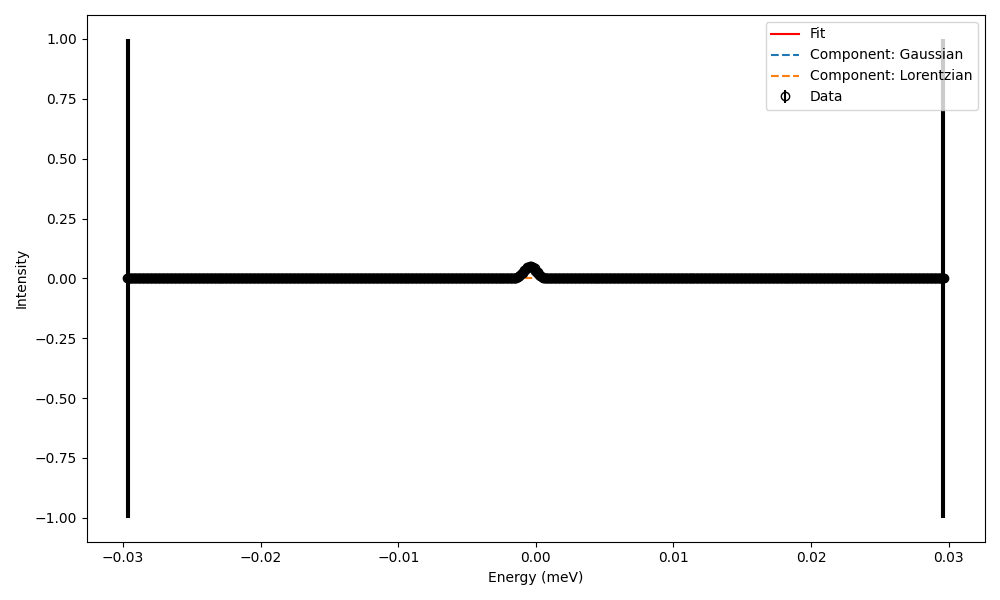

c:\Users\henrikjacobsen3\.conda\envs\EasyQENSDev\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


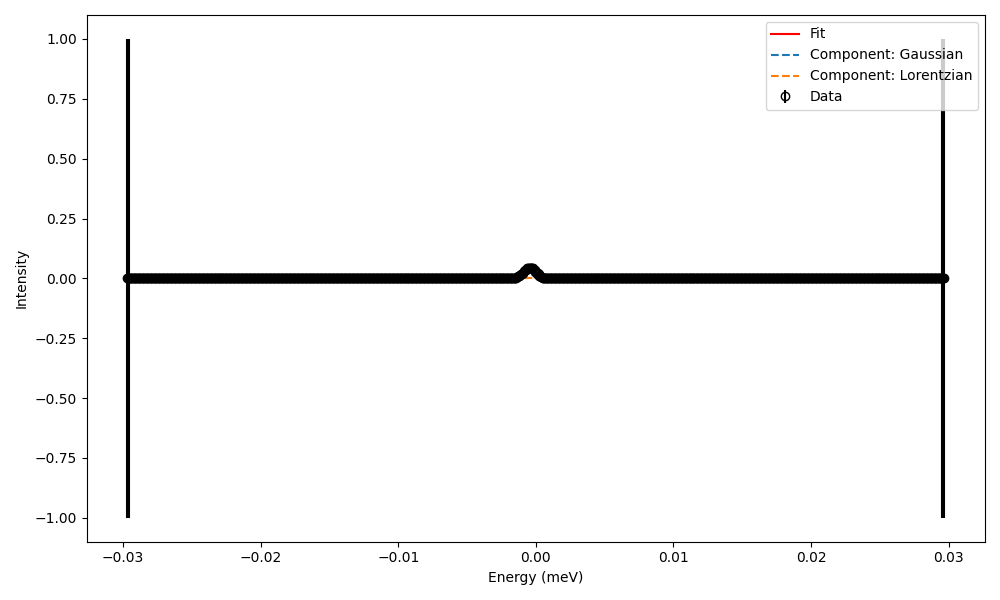

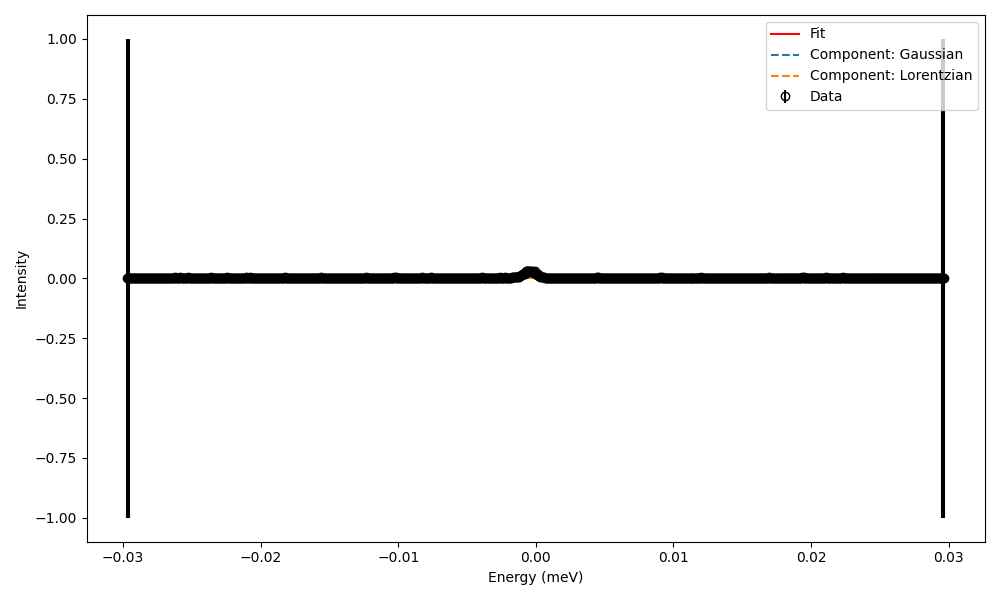

In [8]:


for i in range(len(AllAnalyses)):
    AllAnalyses[i].fit()
    fig = AllAnalyses[i].plot_data_and_model(plot_individual_components=True)
    fig.axes[0].set_xlim(-0.02, 0.02)
    fig.axes[0].set_ylim(0, 0.07)

    


In [9]:
this_analysis.get_parameters()

[<Parameter 'temperature': -1.0000 K (fixed), bounds=[-inf:inf]>,
 <Parameter 'Gaussianarea': 0.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Gaussiancenter': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Gaussianwidth': 0.0004 meV, bounds=[0.0:inf]>,
 <Parameter 'Lorentzianarea': 0.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Lorentziancenter': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Lorentzianwidth': 0.1752 meV, bounds=[0.0:inf]>,
 <Parameter 'temperature': -1.0000 K (fixed), bounds=[-inf:inf]>,
 <Parameter 'Polynomial_c0': 0.0021, bounds=[-inf:inf]>,
 <Parameter 'offset': -0.0005 meV, bounds=[-inf:inf]>]